# FLASH: First Inspection

FLASH writes HDF5 plot files on a PARAMESH block-structured grid. This page opens one, looks at
what it holds, and uses it to settle a question the earlier pages had to leave open.

The run is **GasSloshing**, a galaxy cluster with sloshing intracluster gas: 2.4 Mpc across,
4 refinement levels, about 7.8 million cells.

!!! note "You can download this snapshot"
    It is the `GasSloshing` sample from the yt project:

    ```bash
    curl -O https://yt-project.org/data/GasSloshing.tar.gz
    tar xzf GasSloshing.tar.gz
    ```


## 1. One call to see everything

FLASH writes in CGS, so unlike PLUTO or Athena++ there are no unit constants to supply: the
physical numbers below are real.


In [1]:
using Mera, CairoMakie

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/FLASH/flash_gassloshing/GasSloshing"
ql = quicklook(150; path=path);



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v2.0.0-DEV | Julia 1.12.7 | 8 threads



[ Info: Precompiling MeraMakieExt [defab1b5-6ec5-5409-a2f4-69ec619b2a0e](cache misses: wrong dep version loaded (6))


[ Info: Precompiling MeraMakieExt [defab1b5-6ec5-5409-a2f4-69ec619b2a0e] (cache misses: wrong dep version loaded (12))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Mera v2.0.0-DEV


[Mera]: quicklook output 150, reading gas: 2026-09-15T22:00:45.991



   2169 CPU file(s), levels 7-10 of 10  (full resolution)
   projecting 3 gas map(s) [z, x, y] and the phase diagram from 7774208 cells


┌─ Mera quicklook ── output 150 (FLASH) ───────────────


│ box        : 2400.0 kpc      levels 7–10  (finest 2344.0 pc)
│ grid       : ndim 3 · ncpu 2169 · nvarh 12
│ time       : 3750.0 Myr  (non-cosmological)
│ read       : 7774208 cells  (full resolution)
│ gas mass   : 5.215e13 M⊙
│ nH range   : 1.525e-6 … 0.02711 cm⁻³
│ T  range   : 8.136e6 … 1.043e8 K
└─ 27.94 s ──────────────────────────────────
[Mera]: quicklook output 150 finished: 2026-09-15T22:01:12.539



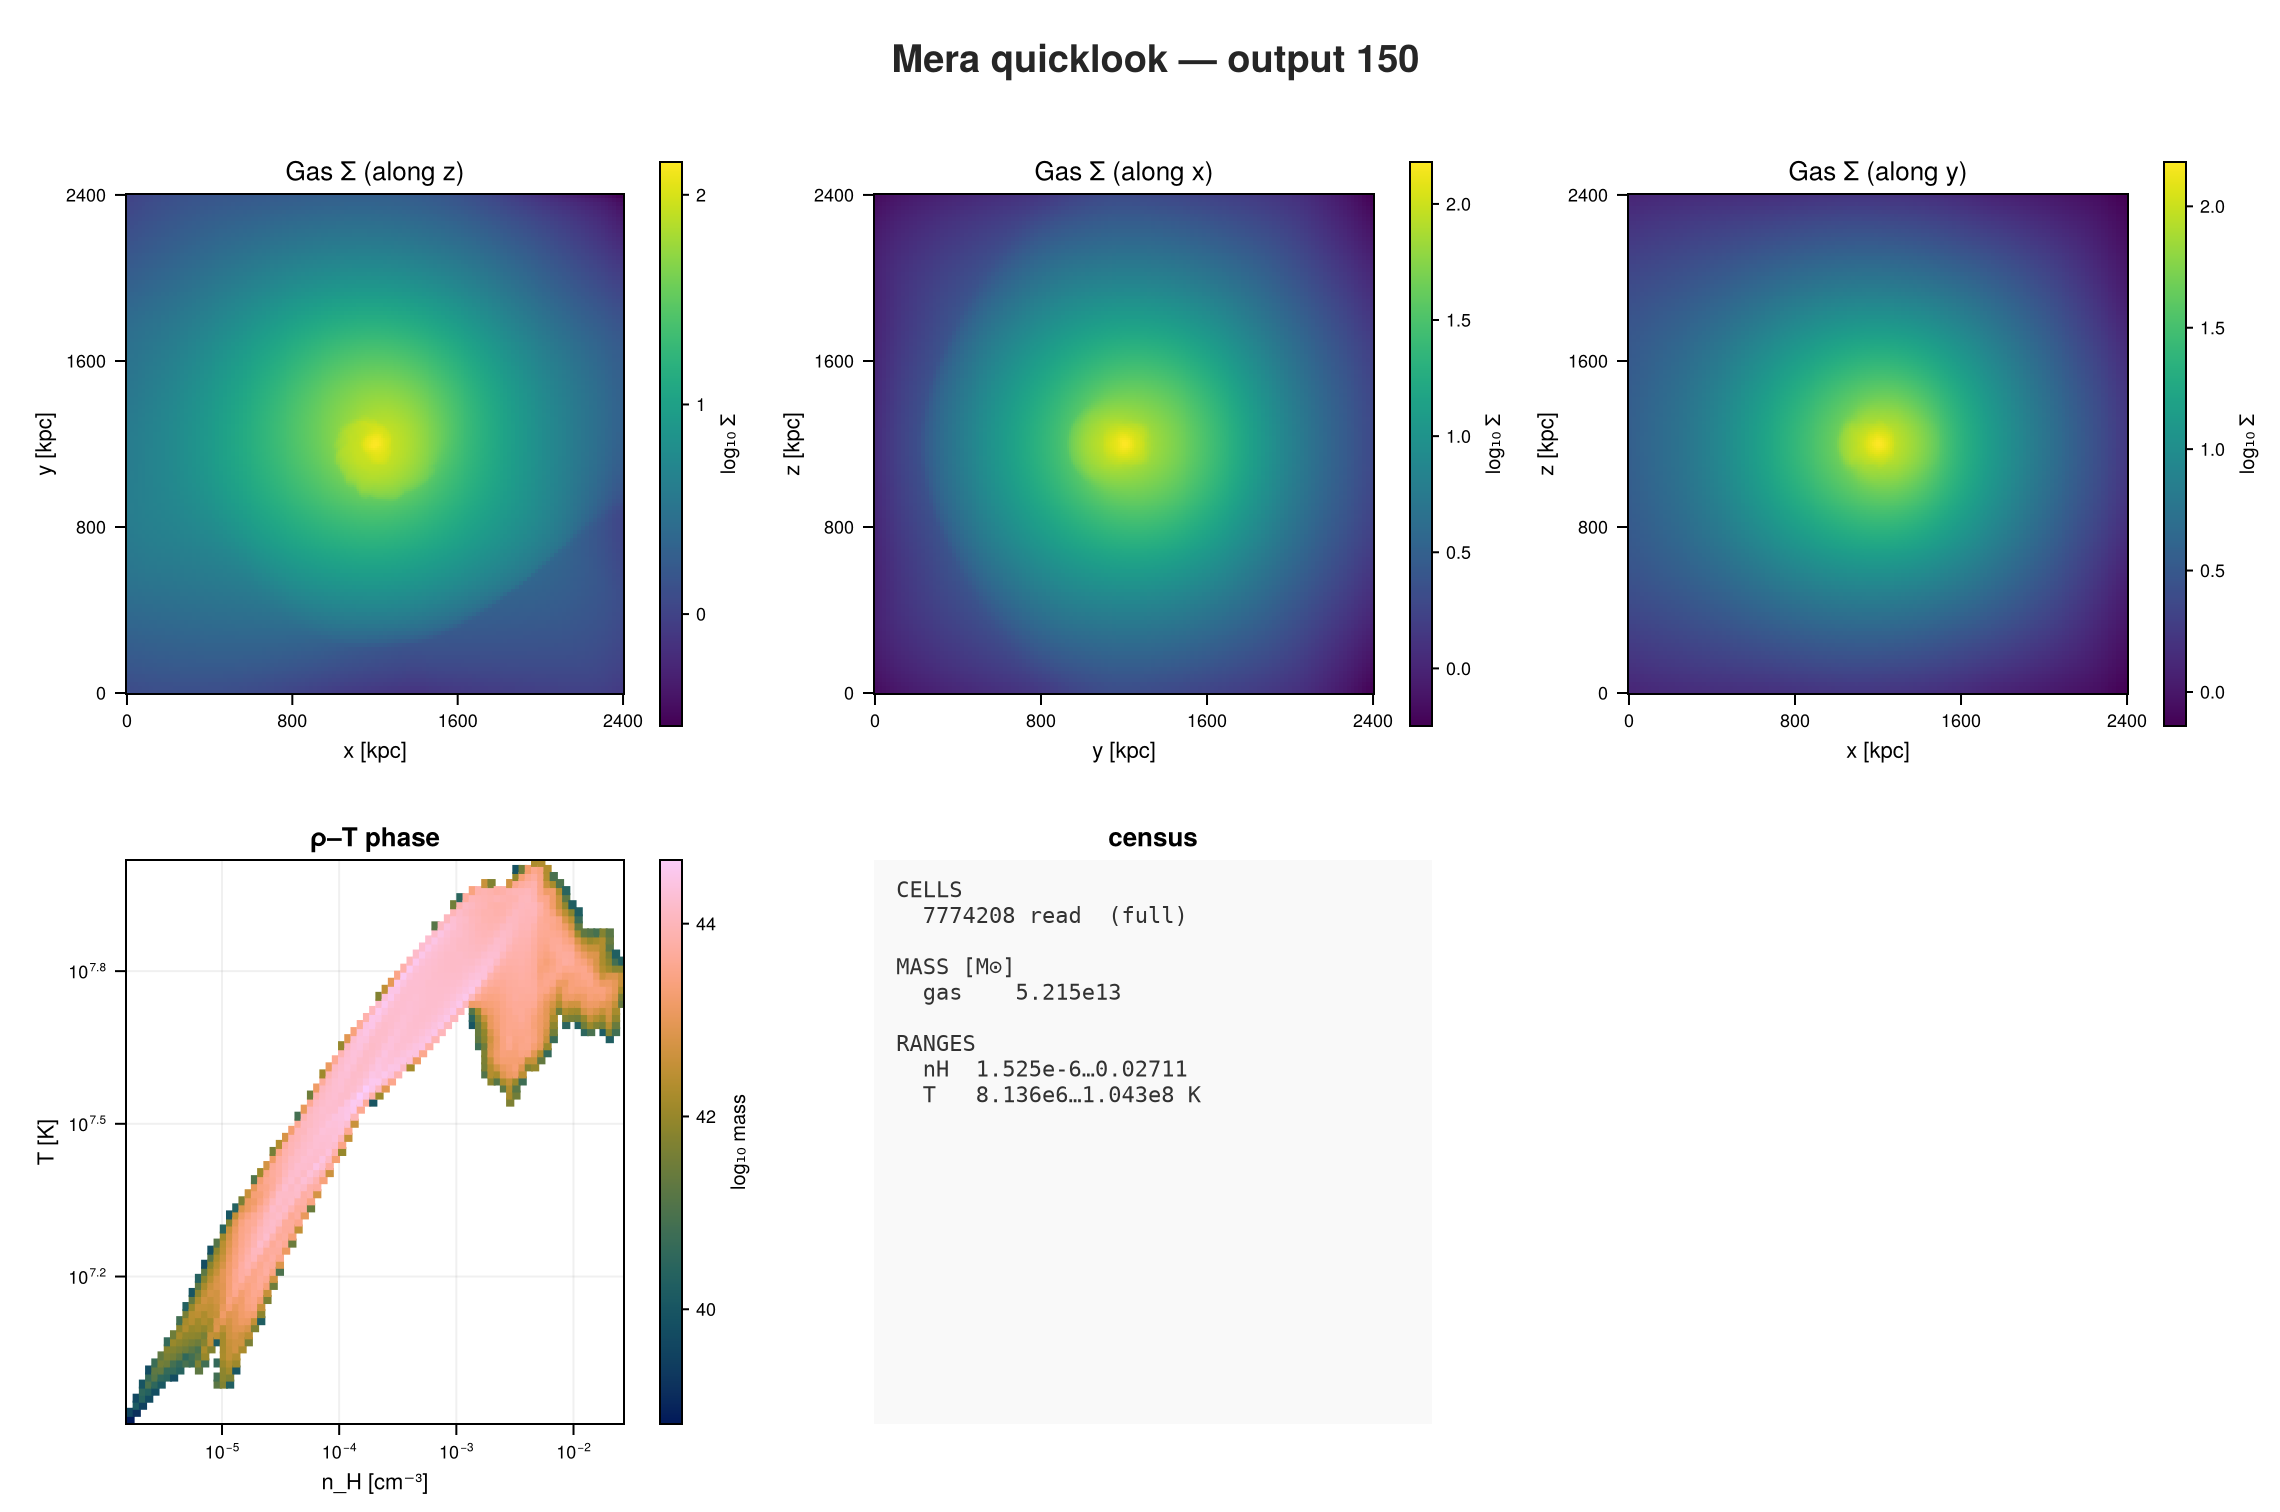

In [2]:
quicklookplot(ql)


## 2. The details: `getinfo`


In [3]:
info = getinfo(150, path);


[Mera]: 2026-09-15T22:01:29.301

Code: FLASH
output: 150  time: 1.1835e17 [code units]
root grid: 16³ (level 4), FLASH lrefine 4:7 ⇒ levels 7:10, boxlen = 7.40544e24
blocks: 2169 (16³ cells each)   variables: (rho, temp, p, gpot, divb, vx, vy, vz, bx, by, bz, magp)
-------------------------------------------------------
[Mera]: FLASH eos_singlespeciesa = 0.5924 used as the mean molecular weight.
[Mera]: composition in use: X = 0.76, mu = 0.5924 (X is the default; the format does not record one)


In [4]:
info.simcode, info.levelmin, info.levelmax, info.variable_list


("FLASH", 7, 10, [:rho, :temp, :p, :gpot, :divb, :vx, :vy, :vz, :bx, :by, :bz, :magp])

A long variable list: density, pressure, velocities, a magnetic field, the gravitational
potential, and **`temp`**, the temperature the simulation itself computed. That last one matters
below.

The scale is a galaxy cluster:


In [5]:
info.boxlen * info.scale.Mpc        # box size in Mpc


2.3999396582866828

In [6]:
info.time * info.scale.Gyr          # snapshot time in Gyr


3.7503140269929554

## 3. What else could be loaded?


In [7]:
capabilities(info)


2-element Vector{Symbol}:
 :info
 :hydro

## 3. Load the gas, and look at the refinement


In [8]:
gas = gethydro(info);


[Mera]: FLASH hydro 7774208 cells, vars rho, temp, p, gpot, divb, vx, vy, vz, bx, by, bz, magp

In [9]:
amroverview(gas)


Counting...


Table with 4 rows, 3 columns:
level  cells    cellsize
──────────────────────────
7      1843200  5.7855e22
8      1777664  2.89275e22
9      1728512  1.44637e22
10     2424832  7.23187e21

In [10]:
gas.data


Table with 7774208 rows, 16 columns:
Columns:
#   colname  type
────────────────────
1   level    Int32
2   cx       Int32
3   cy       Int32
4   cz       Int32
5   rho      Float64
6   temp     Float64
7   p        Float64
8   gpot     Float64
9   divb     Float64
10  vx       Float64
11  vy       Float64
12  vz       Float64
13  bx       Float64
14  by       Float64
15  bz       Float64
16  magp     Float64

In [11]:
msum(gas, :Msol)                    # total gas mass


5.214760643349828e13

## 4. Temperature and density

Most formats do not store a temperature, so Mera derives it from pressure and density. That
needs the mean molecular weight, and **FLASH records it**: `eos_singlespeciesa` in the runtime
parameters, the same value yt reads. The reader applies it, so the derived temperature matches
the simulation with nothing for you to do. `gethydro` prints the value it used.


In [12]:
extrema(getvar(gas, :T, :K))        # Kelvin


(8.136265787700174e6, 1.0433426821483617e8)

If you want to check, the value FLASH itself wrote is in the table as `:temp`:


In [13]:
extrema(getvar(gas, :temp))


(8.13886e6, 1.04367528e8)

In [14]:
extrema(getvar(gas, :rho, :nH))     # cm^-3, with X = 0.76 assumed


(1.5248586047054073e-6, 0.027110935987346135)

On this run it is 0.5924, the value for a fully ionised plasma, which is what a galaxy cluster
is. The two agree to about three parts in 10⁴; the small residual is real, because FLASH's
equation of state is not a pure γ-law.

**Number density is a different matter.** `:nH` needs the hydrogen *mass fraction*, and no
FLASH plot file records one. Mera uses 0.76, the RAMSES convention, and says so rather than
pretending to know. It cannot be recovered from `eos_singlespeciesa` either: that plus the
recorded mean charge do not describe a pure hydrogen-helium mix, so any value would be an
invention. The error is about 1%, and if your run assumes something else, state it:

```julia
setcomposition!(info; X_frac=0.75)   # mu stays as the file recorded it
```


## 5. A projection


In [15]:
proj = projection(gas, :sd, :Msol_pc2, direction=:z, res=256);
size(proj.maps[:sd])


[Mera]: 2026-09-15T22:01:50.207



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 2.4 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 2.4 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 2.4 [Mpc]

Selected var(s)=(:sd,) 
Weighting      = :mass

Effective resolution: 256^2
Map size: 256 x 256
Pixel size: 9.375 [kpc]
Simulation min.: 2.344 [kpc]

Available threads: 8


Requested max_threads: 8
Variables: 1 (sd)
Processing mode: Sequential (single thread)


(256, 256)

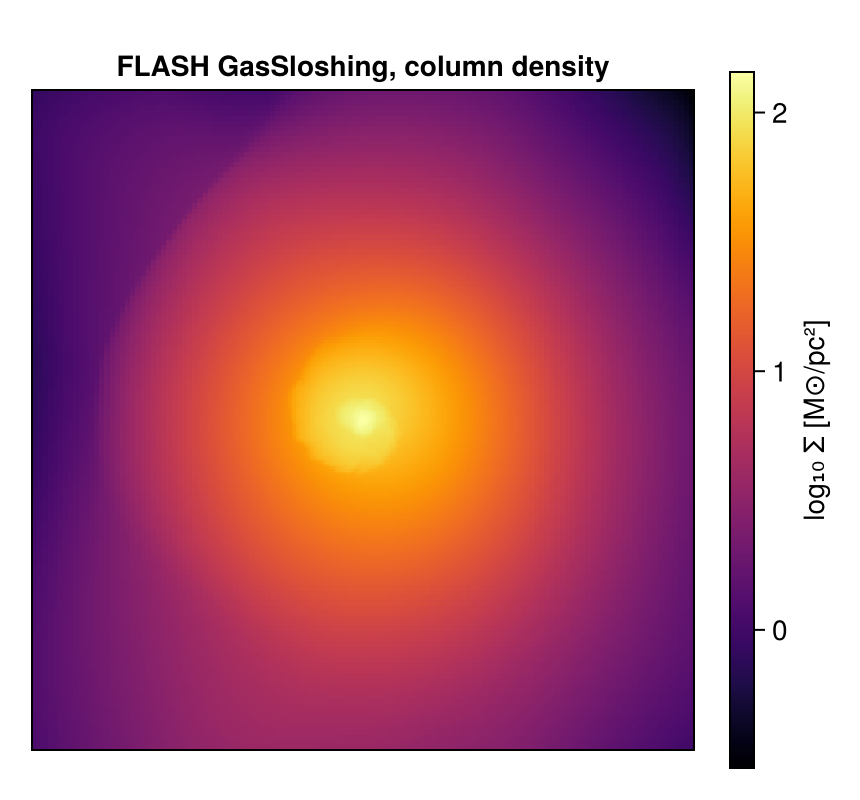

In [16]:
fig = Figure(size=(430, 400))
ax  = Axis(fig[1,1]; title="FLASH GasSloshing, column density", aspect=DataAspect())
hidedecorations!(ax)
hm = heatmap!(ax, log10.(proj.maps[:sd]'); colormap=:inferno)
Colorbar(fig[1,2], hm, label="log₁₀ Σ [M⊙/pc²]")
fig


## Where to go next

The same calls as on every other code, on block-structured AMR, in physical units, with a stored
temperature that let us check Mera's derivation against the simulation's own.

From here every tutorial on this site applies unchanged.
